In [ ]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
import pickle

In [2]:

df = pd.read_csv('diabetes.csv')
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

BATCH_SIZE = 128 
train_ds = tf.data.Dataset.from_tensor_slices((X_train_scaled, y_train)).shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test_scaled, y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [3]:

def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_scaled.shape[1],)))
    
    for i in range(hp.Int('num_layers', 1, 5)):
        model.add(layers.Dense(
            units=hp.Int(f'units_{i}', min_value=32, max_value=256, step=32),
            activation='relu'
        ))
        model.add(layers.Dropout(hp.Float(f'dropout_{i}', 0.1, 0.4, step=0.1)))
    
    model.add(layers.Dense(1, activation='sigmoid'))
    
    lr = hp.Choice('learning_rate', values=[1e-3, 1e-4, 1e-5,1e-6])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10, 
    directory='tuning_results',
    project_name='diabetes_cpu_run'
)

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

tuner.search(
    train_ds, 
    epochs=30, 
    validation_data=test_ds, 
    verbose=1, 
    callbacks=[stop_early]
)

best_model = tuner.get_best_models(num_models=1)[0]
y_pred_probs = best_model.predict(test_ds)
y_pred = (y_pred_probs > 0.45).astype("int32")



Reloading Tuner from tuning_results\diabetes_cpu_run\tuner0.json

111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step



Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.66      0.73      7090
         1.0       0.71      0.84      0.77      7049

    accuracy                           0.75     14139
   macro avg       0.76      0.75      0.75     14139
weighted avg       0.76      0.75      0.75     14139



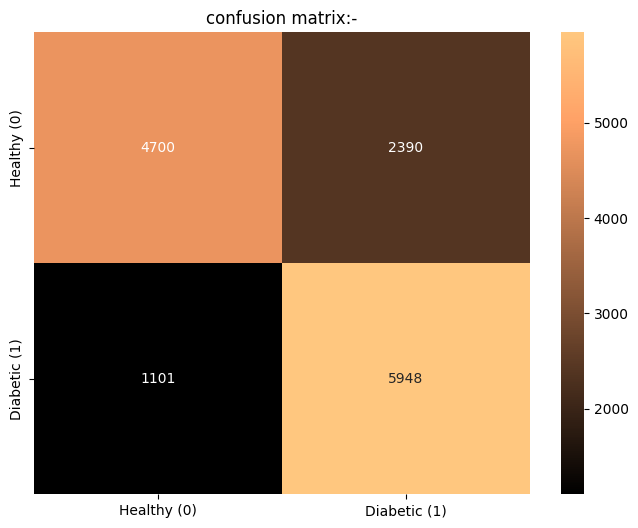

In [4]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='copper', 
            xticklabels=['Healthy (0)', 'Diabetic (1)'], 
            yticklabels=['Healthy (0)', 'Diabetic (1)'])
plt.title('confusion matrix:-')
plt.show()

In [7]:
best_model.save('diabetes_model.keras')
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)